100%|██████████| 170M/170M [00:21<00:00, 8.09MB/s] 


Using device: cuda
Epoch 1/20  Loss: 1.2718  Acc: 64.04%
Epoch 2/20  Loss: 0.9461  Acc: 67.88%
Epoch 3/20  Loss: 0.8282  Acc: 69.41%
Epoch 4/20  Loss: 0.7532  Acc: 71.08%
Epoch 5/20  Loss: 0.6913  Acc: 72.19%
Epoch 6/20  Loss: 0.6468  Acc: 72.58%
Epoch 7/20  Loss: 0.6016  Acc: 73.16%
Epoch 8/20  Loss: 0.5669  Acc: 72.96%
Epoch 9/20  Loss: 0.5325  Acc: 71.97%
Epoch 10/20  Loss: 0.5011  Acc: 72.25%
Epoch 11/20  Loss: 0.4707  Acc: 72.87%
Epoch 12/20  Loss: 0.4463  Acc: 73.80%
Epoch 13/20  Loss: 0.4217  Acc: 72.75%
Epoch 14/20  Loss: 0.4037  Acc: 72.13%
Epoch 15/20  Loss: 0.3760  Acc: 72.40%
Epoch 16/20  Loss: 0.3572  Acc: 72.19%
Epoch 17/20  Loss: 0.3474  Acc: 72.15%
Epoch 18/20  Loss: 0.3230  Acc: 71.89%
Epoch 19/20  Loss: 0.3078  Acc: 72.79%
Epoch 20/20  Loss: 0.2948  Acc: 72.10%


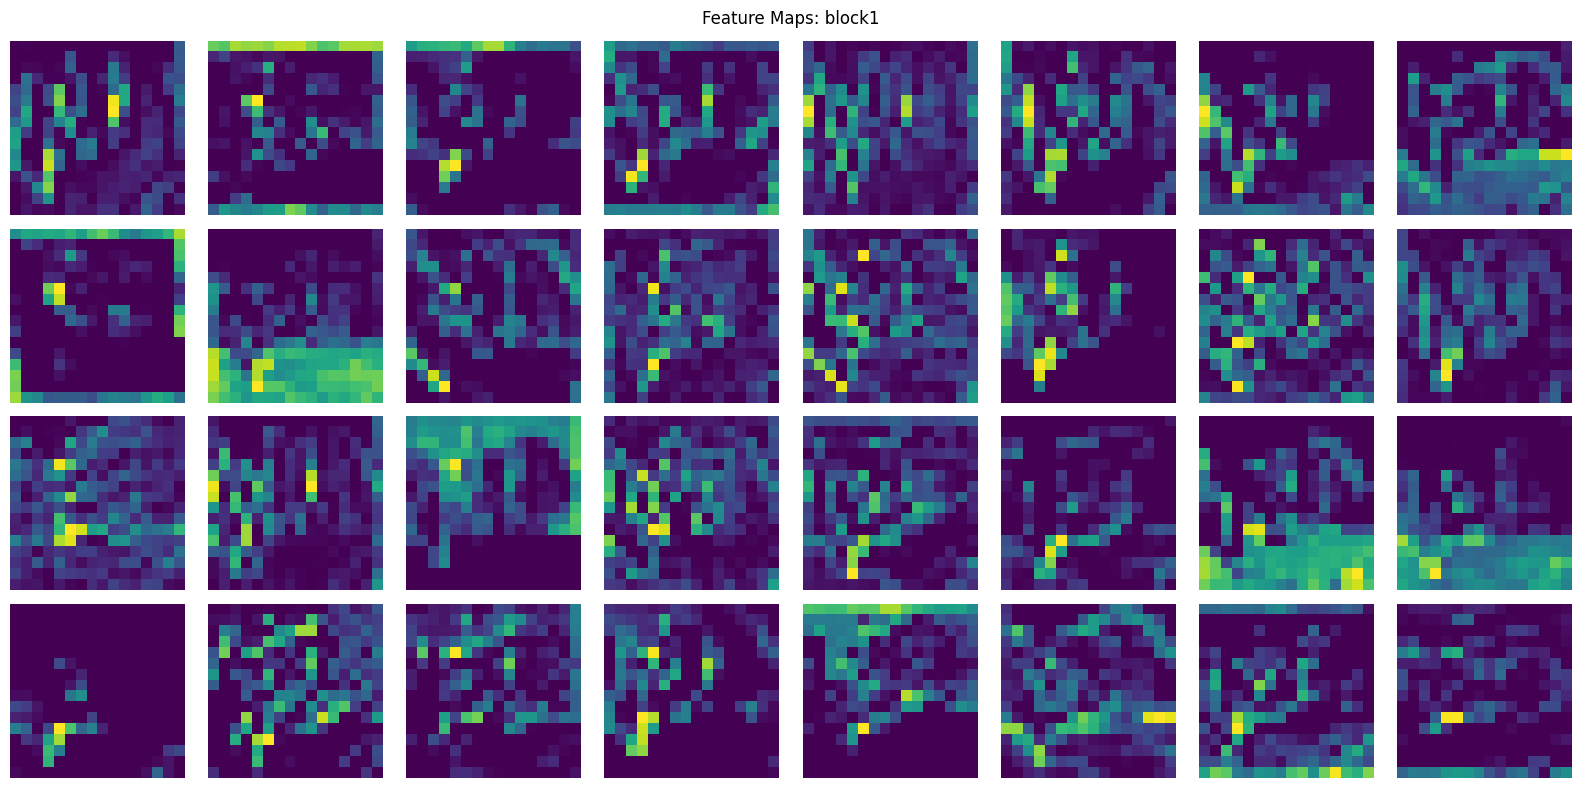

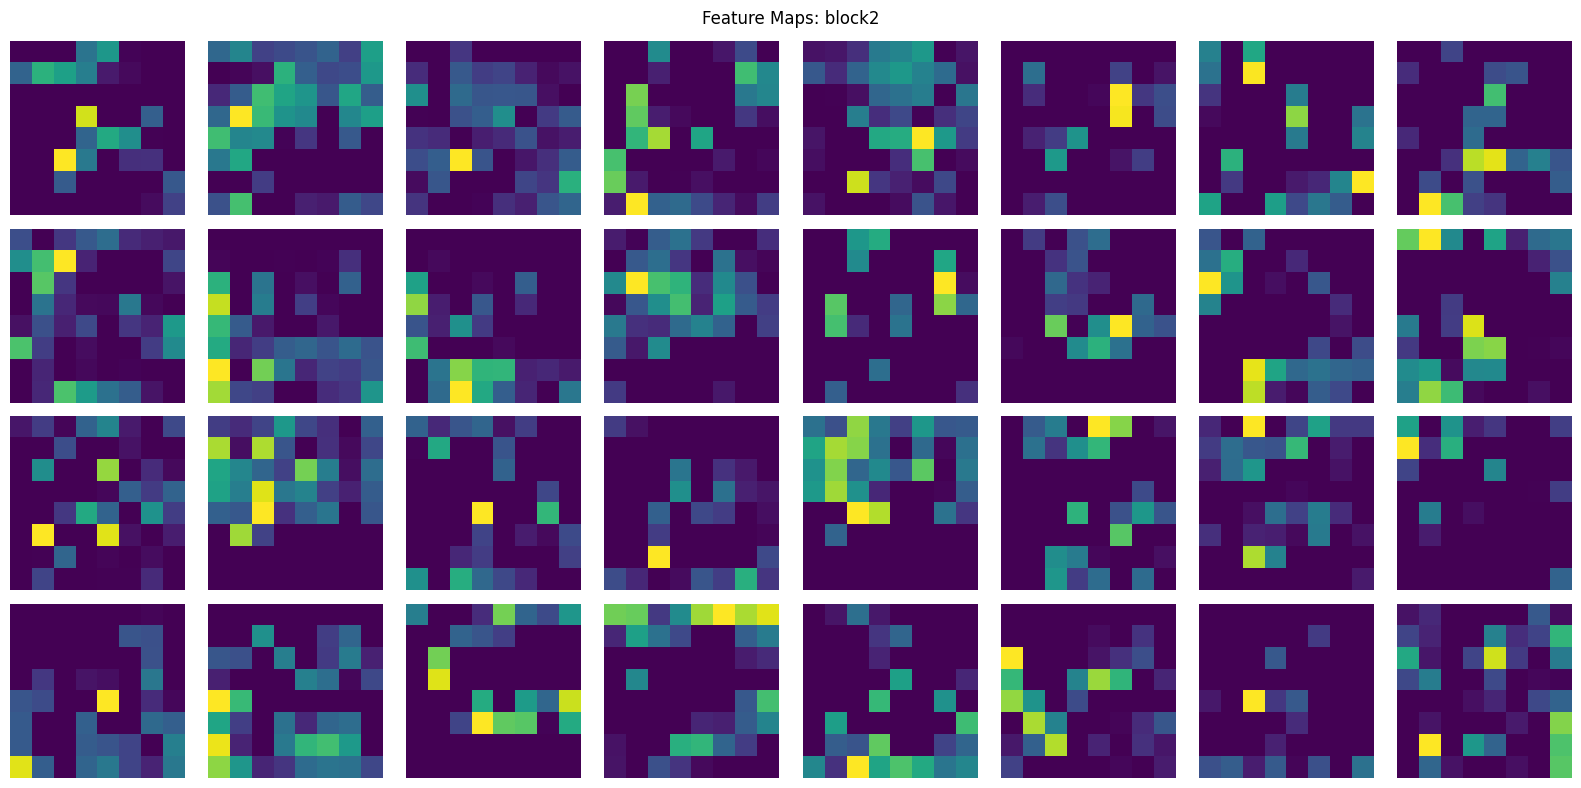

In [1]:
# ============ Q2 - PyTorch CNN ============

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# Model
class CNNModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv_block1 = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        self.conv_block2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        self.fc = nn.Linear(64 * 8 * 8, 10)

    def forward(self, x):
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

# Data
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])
train_data = datasets.CIFAR10('/kaggle/working', train=True, download=True, transform=transform)
test_data  = datasets.CIFAR10('/kaggle/working', train=False, download=True, transform=transform)
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_data,  batch_size=64)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
model = CNNModel().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Train
for epoch in range(20):
    model.train()
    total_loss = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(model(images), labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    # Eval
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            preds = model(images).argmax(1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    print(f"Epoch {epoch+1}/20  Loss: {total_loss/len(train_loader):.4f}  Acc: {100*correct/total:.2f}%")

# Visualize feature maps
activations = {}
model.conv_block1.register_forward_hook(lambda m,i,o: activations.update({'block1': o.detach()}))
model.conv_block2.register_forward_hook(lambda m,i,o: activations.update({'block2': o.detach()}))

sample, _ = test_data[0]
with torch.no_grad():
    model(sample.unsqueeze(0).to(device))

for name, feat in activations.items():
    maps = feat.squeeze(0)
    fig, axes = plt.subplots(4, 8, figsize=(16, 8))
    fig.suptitle(f'Feature Maps: {name}')
    for i, ax in enumerate(axes.flat):
        if i < maps.shape[0]:
            ax.imshow(maps[i].cpu(), cmap='viridis')
        ax.axis('off')
    plt.tight_layout()
    plt.show()